# AppVision Analytics · Launch Readiness Study
## 04 · Playbook and benchmarks

**Brief questions answered here:**
- *What do the apps that broke out in each niche have in common?* (the Playbook)
- *Once we launch, how do we tell whether we're on track?* (the Benchmarks)

**Approach:** The Playbook finds real apps whose names read like a concept within the same category, then compares the ones that passed **100,000 installs** (breakouts) with the ones that didn't. The Benchmarks are percentile tables: for each category and age, how many installs, ratings and stars real apps had. Neither part is a model. Both describe what actually happened in the store.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy import sparse

REPO = Path.cwd().parent
sys.path.insert(0, str(REPO))
from appvision import bands, names
from appvision.benchmark import AGE_LABELS, Benchmarks, build_table
from appvision.client import CONCEPTS
from appvision.playbook import Playbook, installs_label, setup_label
from appvision.style import use_notebook_style, BLUE, ORANGE, INK_2, MUTED, AXIS

use_notebook_style()
ARTIFACTS = REPO / "artifacts"
cols = ["app_id", "app_name", "category", "content_rating", "free", "price_usd", "ad_supported", "in_app_purchases",
        "size_mb", "min_android", "has_website", "has_privacy", "released", "age_days", "days_since_update",
        "rating", "rating_count", "installs", "installs_floor", "dev_prior_apps", "in_model"]
df = pd.read_parquet(REPO / "data" / "v2" / "apps_2021.parquet", columns=cols)
df = df[df["in_model"] == 1].drop(columns="in_model")
print(f"Apps with a valid release date: {len(df):,}")

Apps with a valid release date: 2,241,891


### 1 · Built the Playbook pool
Kept only apps that had been live for **at least a year**, so every app had time to show its outcome. Kept every breakout and a random sample of the rest, small enough to ship with the app. Each sampled app carries a weight equal to the number of real apps it stands for, so breakout rates computed from the pool match the full store.

In [2]:
mature = df[df["age_days"] >= 365].copy()
mature["breakout"] = mature["installs"] >= bands.BREAKOUT_MIN
breakouts = mature[mature["breakout"]]
rest = mature[~mature["breakout"]]
SAMPLE_REST = 350_000
rest_sample = rest.sample(SAMPLE_REST, random_state=11)
weight_rest = len(rest) / SAMPLE_REST

pool = pd.concat([breakouts.assign(weight=1.0), rest_sample.assign(weight=weight_rest)])
pool["weight"] = pool["weight"].astype("float32")
pool = pool.sort_values(["category", "installs"], ascending=[True, False]).reset_index(drop=True)
pool["category"] = pool["category"].astype(str).astype("category")

print(f"Apps live a year or more: {len(mature):,} · breakouts: {len(breakouts):,} ({len(breakouts) / len(mature):.1%})")
print(f"Pool: {len(pool):,} apps (all breakouts + {SAMPLE_REST:,} others, each standing for {weight_rest:.2f} apps)")
check = pool.groupby("category", observed=True).apply(
    lambda g: g.loc[g["breakout"], "weight"].sum() / g["weight"].sum(), include_groups=False)
true_rate = mature.groupby(mature["category"].astype(str))["breakout"].mean()
print(f"Largest gap between pool-estimated and true breakout rate across categories: "
      f"{(check - true_rate.reindex(check.index)).abs().max():.2%}")

Apps live a year or more: 1,786,207 · breakouts: 165,984 (9.3%)
Pool: 515,984 apps (all breakouts + 350,000 others, each standing for 4.63 apps)


Largest gap between pool-estimated and true breakout rate across categories: 1.59%


### 2 · Encoded every pool app's name for look-alike search
Reused the word-level TF-IDF weights fitted in notebook 03, so the Launch Outlook and the Playbook read names the same way. A concept described as "budget and expense tracker" matches *Expense Tracker*, *Budget Planner* and so on, regardless of when those apps were released. That was the v1 recommender's blind spot.

In [3]:
idf = np.load(ARTIFACTS / "name_idf.npy")
name_matrix = names.tfidf(pool["app_name"].astype(str).to_numpy(), idf).tocsr()
name_matrix.sort_indices()
book = Playbook(pool.copy(), name_matrix, idf)
print(f"Name matrix: {name_matrix.shape[0]:,} apps × {name_matrix.shape[1]:,} hashed terms, {name_matrix.nnz:,} non-zeros")

frame, close = book.lookalikes("Finance", "budget and expense tracker")
frame[["app_name", "similarity", "installs_floor", "breakout"]].head(8).assign(
    installs_floor=lambda d: d["installs_floor"].map(installs_label))

Name matrix: 515,984 apps × 1,048,576 hashed terms, 3,046,883 non-zeros


,app_name,similarity,installs_floor,breakout
211438,Spendee - Budget and Expense Tracker & Planner,0.700114,1M+,True
215685,Expense Tracker,0.600284,100K+,True
224820,Expense Tracker,0.600284,10+,False
224694,Expense Tracker,0.600284,10+,False
224077,Expense Tracker,0.600284,50+,False
219539,Budget Calculator -- Planner and Expense Tracker,0.580388,1K+,False
213578,Fudget: Budget and expense tracking app,0.539747,100K+,True
210860,Monefy - Budget Manager and Expense Tracker app,0.510043,5M+,True


### 3 · Ran the Playbook for the studio's three concepts

In [4]:
summary, comparisons, tops = [], {}, {}
for key, concept in CONCEPTS.items():
    frame, close = book.lookalikes(concept.category, concept.title)
    cat_frame, _ = book.lookalikes(concept.category, "")
    comparisons[key] = book.compare(frame)
    tops[key] = book.top_breakouts(frame, n=6)
    summary.append({
        "concept": f"{key} · {concept.title}", "category": concept.category,
        "close matches": len(frame) if close else 0,
        "breakout rate among look-alikes": book.breakout_rate(frame),
        "breakout rate, whole category": book.breakout_rate(cat_frame),
    })
summary = pd.DataFrame(summary).set_index("concept")
summary.style.format({"close matches": "{:,}", "breakout rate among look-alikes": "{:.1%}",
                      "breakout rate, whole category": "{:.1%}"})

,category,close matches,breakout rate among look-alikes,"breakout rate, whole category"
concept,,,,
A · Budget and expense tracker,Finance,103,14.4%,10.3%
B · Offline word puzzle game,Word,120,24.5%,18.9%
C · Exam prep flashcards quiz,Education,149,4.2%,5.8%


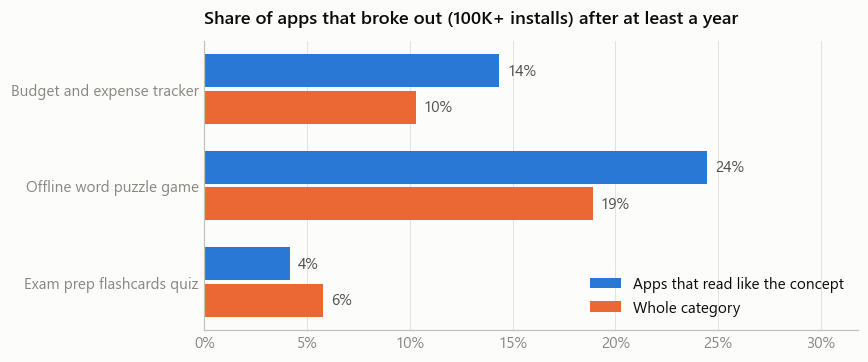

In [5]:
fig, ax = plt.subplots(figsize=(8, 3.4))
y = np.arange(len(summary))[::-1]
h = 0.34
ax.barh(y + h / 2 + 0.02, summary["breakout rate among look-alikes"], height=h, color=BLUE, label="Apps that read like the concept")
ax.barh(y - h / 2 - 0.02, summary["breakout rate, whole category"], height=h, color=ORANGE, label="Whole category")
for yi, a, b in zip(y, summary["breakout rate among look-alikes"], summary["breakout rate, whole category"]):
    ax.annotate(f"{a:.0%}", (a, yi + h / 2 + 0.02), xytext=(5, 0), textcoords="offset points", va="center", color=INK_2)
    ax.annotate(f"{b:.0%}", (b, yi - h / 2 - 0.02), xytext=(5, 0), textcoords="offset points", va="center", color=INK_2)
ax.set_yticks(y, [c.split(" · ")[1] for c in summary.index])
ax.xaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_xlim(0, max(summary.max(numeric_only=True)[["breakout rate among look-alikes", "breakout rate, whole category"]]) * 1.3)
ax.set_title("Share of apps that broke out (100K+ installs) after at least a year")
ax.legend(loc="lower right")
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

In [6]:
def show_comparison(key):
    c = comparisons[key].copy()
    fmt = lambda r, v: f"{v:.0%}" if r["kind"] == "share" else (f"{v:,.0f} MB" if r["column"] == "size_mb" else f"{v:.1f}")
    c["breakouts"] = c.apply(lambda r: fmt(r, r["breakouts"]), axis=1)
    c["others"] = c.apply(lambda r: fmt(r, r["others"]), axis=1)
    return c[["attribute", "breakouts", "others", "note"]].rename(columns={"others": "the rest"})

for key in CONCEPTS:
    print(f"\nConcept {key}: {CONCEPTS[key].title}")
    notes = [n for n in comparisons[key]["note"] if n]
    print("\n".join(f"  • {n}" for n in notes) if notes else "  • no setup choice clearly separated breakouts")


Concept A: Budget and expense tracker
  • 69% of breakouts offered in-app purchases, against 19% of the rest.
  • 93% of breakouts listed a privacy policy, against 71% of the rest.
  • 91% of breakouts listed a studio website, against 53% of the rest.
  • 22% of breakouts came from a studio with earlier apps, against 48% of the rest.
  • 69% of breakouts had been updated in the six months before the snapshot, against 17% of the rest.
  • Breakouts tended to be larger: about 10 MB vs 5 MB.

Concept B: Offline word puzzle game
  • 83% of breakouts offered in-app purchases, against 52% of the rest.
  • 89% of breakouts listed a studio website, against 69% of the rest.
  • 62% of breakouts had been updated in the six months before the snapshot, against 15% of the rest.
  • Breakouts tended to be larger: about 35 MB vs 22 MB.

Concept C: Exam prep flashcards quiz
  • 100% of breakouts were free to download, against 68% of the rest.
  • 80% of breakouts showed ads, against 40% of the rest.


In [7]:
show_comparison("A")

,attribute,breakouts,the rest,note
0,Free to download,100%,97%,
1,Shows ads,67%,55%,
2,Offers in-app purchases,69%,19%,"69% of breakouts offered in-app purchases, aga..."
3,Lists a privacy policy,93%,71%,"93% of breakouts listed a privacy policy, agai..."
4,Lists a studio website,91%,53%,"91% of breakouts listed a studio website, agai..."
5,Studio had published apps before,22%,48%,22% of breakouts came from a studio with earli...
6,Updated in the 6 months before the snapshot,69%,17%,69% of breakouts had been updated in the six m...
7,Rated for everyone,98%,100%,
8,Download size,10 MB,5 MB,Breakouts tended to be larger: about 10 MB vs ...
9,Minimum Android version,4.4,4.2,


In [8]:
show_comparison("B")

,attribute,breakouts,the rest,note
0,Free to download,100%,100%,
1,Shows ads,99%,98%,
2,Offers in-app purchases,83%,52%,"83% of breakouts offered in-app purchases, aga..."
3,Lists a privacy policy,99%,92%,
4,Lists a studio website,89%,69%,"89% of breakouts listed a studio website, agai..."
5,Studio had published apps before,75%,60%,
6,Updated in the 6 months before the snapshot,62%,15%,62% of breakouts had been updated in the six m...
7,Rated for everyone,94%,92%,
8,Download size,35 MB,22 MB,Breakouts tended to be larger: about 35 MB vs ...
9,Minimum Android version,4.4,4.1,


In [9]:
show_comparison("C")

,attribute,breakouts,the rest,note
0,Free to download,100%,68%,"100% of breakouts were free to download, again..."
1,Shows ads,80%,40%,"80% of breakouts showed ads, against 40% of th..."
2,Offers in-app purchases,80%,19%,"80% of breakouts offered in-app purchases, aga..."
3,Lists a privacy policy,96%,84%,
4,Lists a studio website,96%,69%,"96% of breakouts listed a studio website, agai..."
5,Studio had published apps before,84%,93%,
6,Updated in the 6 months before the snapshot,72%,6%,72% of breakouts had been updated in the six m...
7,Rated for everyone,100%,91%,
8,Download size,16 MB,5 MB,Breakouts tended to be larger: about 16 MB vs ...
9,Minimum Android version,4.1,4.1,


**Breakouts in each niche worth studying** (as listed in June 2021):

In [10]:
listing = []
for key, top in tops.items():
    for r in top.itertuples():
        listing.append({"concept": key, "app": str(r.app_name)[:48], "installs": installs_label(r.installs_floor),
                        "rating": f"{r.rating:.1f}", "setup": setup_label(r._asdict()),
                        "launched": pd.Timestamp(r.released).year})
pd.DataFrame(listing)

,concept,app,installs,rating,setup,launched
0,A,Spendee - Budget and Expense Tracker & Planner,1M+,3.1,Free · ads · in-app purchases,2013
1,A,Expense Tracker,100K+,3.5,Free · ads,2010
2,A,Fudget: Budget and expense tracking app,100K+,4.7,Free · ads · in-app purchases,2017
3,A,Monefy - Budget Manager and Expense Tracker app,5M+,4.5,Free · ads · in-app purchases,2014
4,A,Budget Planner & Expense Tracker,100K+,4.0,Free · ads,2017
5,A,Financial Architect - income and expense tracker,100K+,4.7,Free · ads · in-app purchases,2016
6,B,Word Hunter - Offline Word Puzzle Game 🇺🇸,100K+,4.0,Free · ads · in-app purchases,2018
7,B,Word Search game 2021 ✏️📚 - Free word puzzle gam,500K+,4.5,Free · ads,2016
8,B,Emoji Trivia - Word Puzzle Game,100K+,4.5,Free · ads · in-app purchases,2018
9,B,Word Puzzle - Word Games Offline,100K+,4.3,Free · ads · in-app purchases,2015


### 4 · Built the Benchmark tables
For every category and time-on-store band (0–3 months up to 3–5 years), recorded the 1st–99th percentiles of three things a live app can check against:
- **installs**
- **ratings per 1,000 installs**: how often users leave a rating at all (apps with 100+ installs)
- **star rating**: apps with at least 10 ratings, since a few early ratings swing averages a lot

Groups with fewer than 30 apps were left out rather than shown with false precision.

In [11]:
live = df[df["age_days"] < 1826]
table = build_table(live, None)
bench = Benchmarks(table)
print(f"Benchmark rows: {len(table):,} (category × age band × metric) built from {len(live):,} apps")
print(f"Median peers per row: {table['peers'].median():,.0f}")

example = dict(category="Word", age_band=2, installs=4_000)
pct, peers = bench.percentile(example["category"], example["age_band"], "installs", example["installs"])
print(f"\nExample: a Word app live {AGE_LABELS[2]} with 4,000 installs is ahead of {pct:.0f}% of {peers:,} peers.")

Benchmark rows: 863 (category × age band × metric) built from 1,896,246 apps
Median peers per row: 1,770

Example: a Word app live 6–12 months with 4,000 installs is ahead of 71% of 1,052 peers.


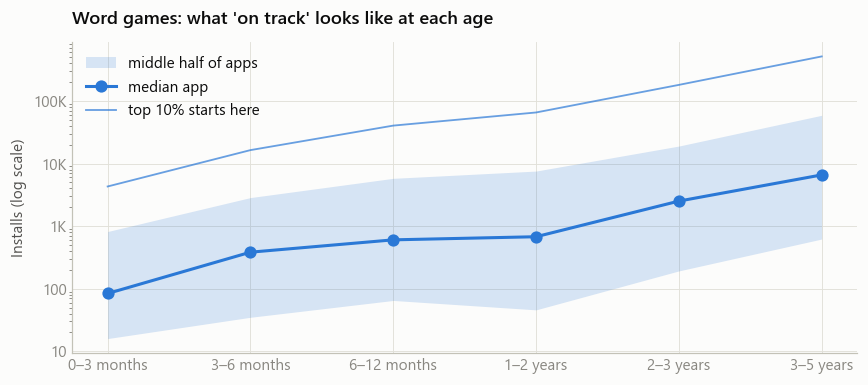

,bottom quarter,median,top quarter,top 10%,apps
time on store,,,,,
0–3 months,16,84,821,"4,308",249
3–6 months,35,384,"2,863","16,422",380
6–12 months,65,604,"5,813","40,461","1,052"
1–2 years,46,678,"7,592","65,596","2,131"
2–3 years,193,"2,516","19,060","181,027","1,284"
3–5 years,623,"6,593","59,139","515,571","1,811"


In [12]:
curve_rows = []
for b, label in enumerate(AGE_LABELS):
    vals, n = bench.curve("Word", b, "installs")
    if vals is not None:
        curve_rows.append({"time on store": label, "bottom quarter": vals[24], "median": vals[49],
                           "top quarter": vals[74], "top 10%": vals[89], "apps": n})
word_curve = pd.DataFrame(curve_rows).set_index("time on store")

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(len(word_curve))
ax.fill_between(x, word_curve["bottom quarter"], word_curve["top quarter"], color=BLUE, alpha=0.18, linewidth=0,
                label="middle half of apps")
ax.plot(x, word_curve["median"], color=BLUE, marker="o", markersize=7, label="median app")
ax.plot(x, word_curve["top 10%"], color=BLUE, linewidth=1.2, alpha=0.7, label="top 10% starts here")
ax.set_yscale("log")
ax.set_xticks(x, word_curve.index)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: installs_label(v).rstrip("+") if v >= 1 else "0"))
ax.set_ylabel("Installs (log scale)")
ax.set_title("Word games: what 'on track' looks like at each age")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()
word_curve.style.format("{:,.0f}")

### 5 · Saved the app's files

In [13]:
keep = ["app_id", "app_name", "category", "content_rating", "free", "price_usd", "ad_supported", "in_app_purchases",
        "size_mb", "min_android", "has_website", "has_privacy", "released", "days_since_update", "rating",
        "rating_count", "installs", "installs_floor", "dev_prior_apps", "breakout", "weight"]
pool[keep].to_parquet(ARTIFACTS / "playbook_pool.parquet", index=False, compression="zstd")
sparse.save_npz(ARTIFACTS / "playbook_names.npz", name_matrix, compressed=True)
table.to_parquet(ARTIFACTS / "benchmarks.parquet", index=False, compression="zstd")
for f in ["playbook_pool.parquet", "playbook_names.npz", "benchmarks.parquet"]:
    print(f"{f:<24} {(ARTIFACTS / f).stat().st_size / 1e6:6.1f} MB")

playbook_pool.parquet      20.6 MB
playbook_names.npz         18.7 MB
benchmarks.parquet          0.4 MB


### Takeaways for the studio
- **Word puzzles are the healthiest niche of the three.** 24.5% of apps that read like concept B broke out (100K+ installs) after a year or more, above the Word category's 18.9%. Budget trackers came in at 14.4% and exam-prep apps at 4.2%.
- **B's breakouts were fuller games.** 83% offered in-app purchases (against 52% of the rest), and they were bigger downloads, about 35 MB vs 22 MB. That points to polish and content depth over a minimal build.
- **Breakouts kept shipping updates.** In every niche, 62–72% of breakouts had been updated in the six months before the snapshot, against 6–17% of the rest. Part of that is a result of success, since popular apps get maintained. Still, no niche rewarded an abandoned app, so a year-one update cadence belongs in the plan.
- **Exam prep is crowded with focused brands.** Its breakouts were exam-specific (NEET, RRB, TNPSC prep), which a general flashcards app would have to out-compete.
- **On-track markers for a Word game at 6–12 months:** the median app has about 600 installs, the top quarter starts near 5,800 and the top 10% near 40,000. A Word app with 4,000 installs at that age is ahead of 71% of its 1,052 peers.